import các thư viện cần thiết và tải các tệp đã qua tiền xử lý

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # Dùng để lưu model
import gc      # Dùng để quản lý bộ nhớ

events_file_path = '../data/processed/events_cleaned.csv'
item_file_path = '../data/processed/item_info_cleaned.csv'
category_file_path = '../data/processed/category_tree_cleaned.csv'

try:
    # Tải dữ liệu
    events_df = pd.read_csv(events_file_path)
    item_df = pd.read_csv(item_file_path)
    category_df = pd.read_csv(category_file_path)

    print("Tải dữ liệu thành công!")
    print("\nThông tin `events_df` (dữ liệu hành vi chính):")
    events_df.info()

    print("\nThông tin `item_df` (dữ liệu sản phẩm):")
    item_df.info()

except FileNotFoundError:
    print(f"LỖI: Không tìm thấy file tại '{events_file_path}'.")

Tải dữ liệu thành công!

Thông tin `events_df` (dữ liệu hành vi chính):
<class 'pandas.DataFrame'>
RangeIndex: 4259061 entries, 0 to 4259060
Data columns (total 8 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      str    
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  int64  
 5   categoryid     float64
 6   available      float64
 7   parentid       float64
dtypes: float64(3), int64(3), str(2)
memory usage: 370.5 MB

Thông tin `item_df` (dữ liệu sản phẩm):
<class 'pandas.DataFrame'>
RangeIndex: 513503 entries, 0 to 513502
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   itemid      513503 non-null  int64
 1   categoryid  513503 non-null  int64
 2   available   513503 non-null  int64
dtypes: int64(3)
memory usage: 11.8 MB


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

Trích xuất đặc trưng:
Đây là bước quan trọng nhất. Chúng ta cần biến đổi dữ liệu log hành vi (dạng chuỗi sự kiện) thành các đặc trưng cố định cho mỗi visitorid để mô hình có thể học được.
Bài toán: Chúng ta muốn dự đoán khả năng một visitorid sẽ "chuyển đổi" (mua hàng). Vì vậy, chúng ta sẽ nhóm tất cả các hành vi theo visitorid.
Biến mục tiêu (Label): converted (1 nếu có 'transaction', 0 nếu không).

In [3]:
# Chuyển đổi cột 'timestamp' sang định dạng datetime để có thể trích xuất đặc trưng thời gian
events_df['timestamp'] = pd.to_datetime(events_df['timestamp'])

print("Bắt đầu trích xuất đặc trưng...")

#  1. Đặc trưng về hành vi (Event Counts)
# Đếm số lần mỗi visitor thực hiện từng loại hành vi
event_features = events_df.pivot_table(
    index='visitorid',
    columns='event',
    aggfunc='size',
    fill_value=0
)

# Đổi tên cột để dễ quản lý (ví dụ: 'view' -> 'event_view')
event_features.columns = ['event_' + col for col in event_features.columns]

# 2. Đặc trưng về sản phẩm và danh mục (Item/Category)
visitor_agg_features = events_df.groupby('visitorid').agg(
    total_events=('event', 'count'),          # Tổng số hành động
    unique_items_viewed=('itemid', 'nunique'), # Số sản phẩm
    unique_categories_viewed=('categoryid', 'nunique') # Số danh mục
)

# 3. Đặc trưng về thời gian (Temporal)
# Tính độ dài của phiên (session) của mỗi visitor
visitor_time_features = events_df.groupby('visitorid')['timestamp'].agg(['min', 'max'])
visitor_time_features['session_duration_seconds'] = (visitor_time_features['max'] - visitor_time_features['min']).dt.total_seconds()

# Trích xuất đặc trưng về giờ trong ngày (sáng, trưa, chiều, tối)
events_df['hour_of_day'] = events_df['timestamp'].dt.hour
visitor_hour_features = events_df.groupby('visitorid')['hour_of_day'].agg(
    most_frequent_hour=lambda x: x.mode()[0] # Giờ hoạt động chủ yếu
)

# 4. Merge tất cả các đặc trưng lại
features_df = event_features.join(visitor_agg_features).join(visitor_time_features[['session_duration_seconds']]).join(visitor_hour_features)

# Giải phóng bộ nhớ (quan trọng khi làm việc với file lớn)
del visitor_agg_features, visitor_time_features, visitor_hour_features
gc.collect()

# 5. Định nghĩa Biến Mục tiêu (Label)
# "Chuyển đổi" (converted) được định nghĩa là visitor có ít nhất 1 sự kiện 'transaction'.
# Kiểm tra xem cột 'event_transaction' có tồn tại không (được tạo từ pivot_table)
if 'event_transaction' not in features_df.columns:
    print("Cảnh báo: Không tìm thấy sự kiện 'transaction'. Mặc định tất cả là 0.")
    features_df['event_transaction'] = 0

features_df['converted'] = (features_df['event_transaction'] > 0).astype(int)

# In ra tỉ lệ chuyển đổi
conversion_rate = features_df['converted'].mean()
print(f"\nTỉ lệ chuyển đổi tổng thể trong dữ liệu: {conversion_rate:.2%}")

# Xử lý các giá trị NaN (nếu có)
features_df = features_df.fillna(0)

print("Trích xuất đặc trưng hoàn tất!")
print(f"Tổng số visitor (samples): {features_df.shape[0]}")
print(f"Tổng số đặc trưng (features) đã trích xuất: {features_df.shape[1] - 1}") # Trừ cột 'converted'
features_df.head()

Bắt đầu trích xuất đặc trưng...



Tỉ lệ chuyển đổi tổng thể trong dữ liệu: 0.83%
Trích xuất đặc trưng hoàn tất!
Tổng số visitor (samples): 1407580
Tổng số đặc trưng (features) đã trích xuất: 8


,event_addtocart,event_transaction,event_view,total_events,unique_items_viewed,unique_categories_viewed,session_duration_seconds,most_frequent_hour,converted
visitorid,,,,,,,,,
0,0,0,5,5,3,3,327.736,20,0
1,0,0,1,1,1,1,0.000,17,0
2,0,0,12,12,4,2,1753.278,17,0
3,0,0,1,1,1,1,0.000,7,0
4,0,0,1,1,1,0,0.000,21,0


Chuẩn bị dữ liệu cho Model:
chúng ta sẽ tách bộ dữ liệu thành tập Huấn luyện (Train) và tập Kiểm tra (Test).

In [4]:
# Tách Features (X) và Label (y)
y = features_df['converted']
# X là tất cả các cột trừ cột label 'converted' và cột 'event_transaction' (vì nó định nghĩa label)
X = features_df.drop(columns=['converted', 'event_transaction'])

# --- Phân chia Train/Test ---
# Chúng ta sẽ dùng 80% dữ liệu để huấn luyện và 20% để kiểm tra
# stratify=y đảm bảo tỉ lệ chuyển đổi (0 và 1) trong tập train và test là tương đương nhau.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Kích thước tập Train (features): {X_train.shape}")
print(f"Kích thước tập Test (features): {X_test.shape}")
print(f"Tỉ lệ chuyển đổi trong tập Train: {y_train.mean():.2%}")
print(f"Tỉ lệ chuyển đổi trong tập Test: {y_test.mean():.2%}")

# --- Chuẩn hóa (Scaling) và Mã hóa (Encoding) Đặc trưng ---

# Xác định các cột số (numerical) và cột hạng mục (categorical)
# 'most_frequent_hour' là categorical, các cột event_... và session... là numerical
categorical_cols = ['most_frequent_hour']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# 1. Chuẩn hóa (StandardScaler) cho các cột số:
# Giúp các thuật toán (như Logistic Regression) hội tụ nhanh hơn.
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 2. Mã hóa One-Hot (OneHotEncoder) cho các cột hạng mục:
# Biến cột 'most_frequent_hour' (0-23) thành 24 cột nhị phân (0/1)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# Lấy tên cột mới sau khi encoding
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Ghép lại với dữ liệu số đã scale
X_train_final = pd.concat([
    pd.DataFrame(X_train[numerical_cols], index=X_train.index),
    pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
], axis=1)

X_test_final = pd.concat([
    pd.DataFrame(X_test[numerical_cols], index=X_test.index),
    pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)
], axis=1)

print("\nChuẩn hóa và Encoding hoàn tất.")
X_train_final.head()

Kích thước tập Train (features): (1126064, 7)
Kích thước tập Test (features): (281516, 7)
Tỉ lệ chuyển đổi trong tập Train: 0.83%
Tỉ lệ chuyển đổi trong tập Test: 0.83%



Chuẩn hóa và Encoding hoàn tất.


,event_addtocart,event_view,total_events,unique_items_viewed,unique_categories_viewed,session_duration_seconds,most_frequent_hour_0,most_frequent_hour_1,most_frequent_hour_2,most_frequent_hour_3,...,most_frequent_hour_14,most_frequent_hour_15,most_frequent_hour_16,most_frequent_hour_17,most_frequent_hour_18,most_frequent_hour_19,most_frequent_hour_20,most_frequent_hour_21,most_frequent_hour_22,most_frequent_hour_23
visitorid,,,,,,,,,,,,,,,,,,,,,
1383160,-0.040896,-0.099065,-0.091259,-0.069946,-0.052860,-0.204280,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
932839,-0.040896,-0.099065,-0.091259,-0.069946,-0.052860,-0.204280,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
418771,-0.040896,0.263959,0.224277,0.597142,0.861416,-0.203991,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
873472,-0.040896,0.263959,0.224277,-0.069946,-0.052860,-0.204185,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
574446,-0.040896,-0.099065,-0.091259,-0.069946,-0.052860,-0.204280,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Lựa chọn, Huấn luyện (Training).
Chúng ta sẽ thử 2 mô hình:
- Logistic Regression: Một mô hình cơ bản (baseline) nhanh, hiệu quả và dễ diễn giải.
- Random Forest: Một mô hình mạnh mẽ hơn, xử lý tốt các mối quan hệ phi tuyến tính và cho phép chúng ta xem mức độ quan trọng của đặc trưng (Feature Importance).

Model Random Forest Classifier

In [5]:
print("Bắt đầu huấn luyện Model 2: Random Forest Classifier...")

# n_estimators=100 là số lượng "cây" trong "rừng"
# class_weight='balanced'
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1 # Sử dụng tất cả các CPU core để chạy nhanh hơn
)

rf_model.fit(X_train_final, y_train)

print("Huấn luyện Random Forest hoàn tất!")

Bắt đầu huấn luyện Model 2: Random Forest Classifier...


Huấn luyện Random Forest hoàn tất!


Đánh giá model

Bắt đầu đánh giá model trên tập Test...


--- KẾT QUẢ ĐÁNH GIÁ (MODEL: RandomForestClassifier) ---
Accuracy: 0.9971 (Độ chính xác tổng thể)
Precision: 0.9174 (Trong số các dự đoán 'Converted', bao nhiêu % là đúng)
Recall: 0.7108 (Trong số các ca 'Converted' thật, model phát hiện được bao nhiêu %)
F1-Score: 0.8010 (Trung bình điều hòa của Precision và Recall)
ROC-AUC: 0.9983 (Khả năng phân loại của model, 1.0 là hoàn hảo)



Đã lưu 'evaluation_confusion_matrix.png'


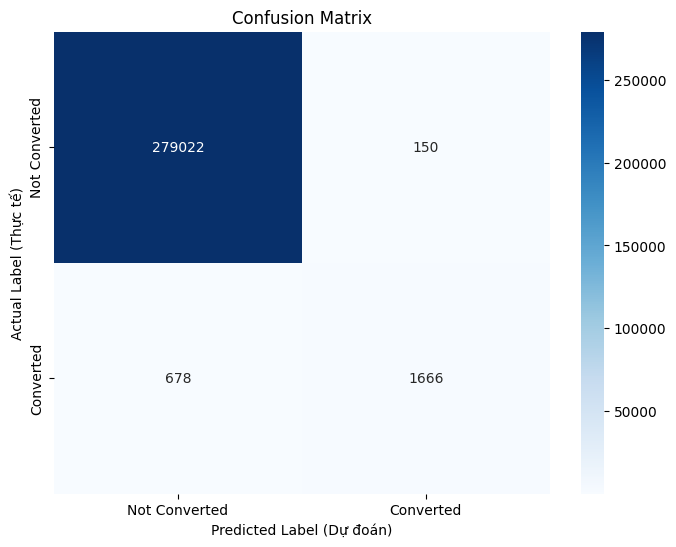

Đã lưu 'evaluation_roc_curve.png'


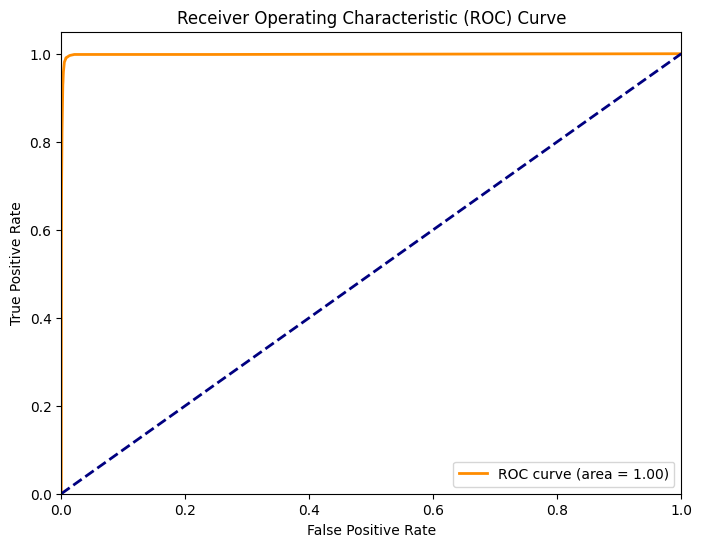

Đã lưu 'evaluation_feature_importance.png'


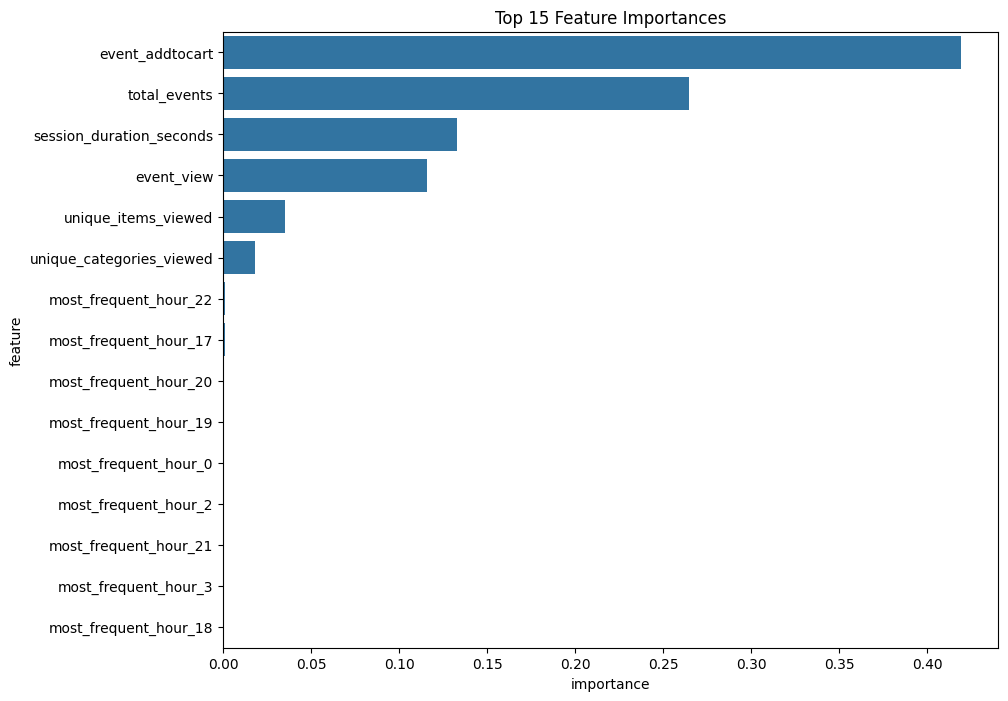

In [6]:
print("Bắt đầu đánh giá model trên tập Test...")

# Chọn model để đánh giá (rf_model)
model_to_evaluate = rf_model

# Dự đoán trên tập Test
y_pred = model_to_evaluate.predict(X_test_final)
y_pred_proba = model_to_evaluate.predict_proba(X_test_final)[:, 1] # Lấy xác suất của class 1 (converted)

# Tính toán các chỉ số
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"--- KẾT QUẢ ĐÁNH GIÁ (MODEL: {model_to_evaluate.__class__.__name__}) ---")
print(f"Accuracy: {accuracy:.4f} (Độ chính xác tổng thể)")
print(f"Precision: {precision:.4f} (Trong số các dự đoán 'Converted', bao nhiêu % là đúng)")
print(f"Recall: {recall:.4f} (Trong số các ca 'Converted' thật, model phát hiện được bao nhiêu %)")
print(f"F1-Score: {f1:.4f} (Trung bình điều hòa của Precision và Recall)")
print(f"ROC-AUC: {roc_auc:.4f} (Khả năng phân loại của model, 1.0 là hoàn hảo)")

# Vẽ biểu đồ

# 1. Confusion Matrix (Ma trận nhầm lẫn)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label (Thực tế)')
plt.xlabel('Predicted Label (Dự đoán)')
plt.savefig('evaluation_confusion_matrix.png') # Lưu biểu đồ
print("\nĐã lưu 'evaluation_confusion_matrix.png'")
plt.show()

# 2. ROC Curve (Đường cong ROC)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('evaluation_roc_curve.png') # Lưu biểu đồ
print("Đã lưu 'evaluation_roc_curve.png'")
plt.show()

# 3. Feature Importance (Mức độ quan trọng của đặc trưng)
importances = model_to_evaluate.feature_importances_
feature_names = X_train_final.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15)) # 15 đặc trưng quan trọng nhất
plt.title('Top 15 Feature Importances')
plt.savefig('evaluation_feature_importance.png') # Lưu biểu đồ
print("Đã lưu 'evaluation_feature_importance.png'")
plt.show()

Trả về kết quả

In [7]:
print("Lưu các file kết quả cho Giai đoạn 3...")

# 1. Lưu model đã train
# Chúng ta sẽ lưu một "pipeline" bao gồm scaler, encoder và model
model_pipeline = {
    'scaler': scaler,
    'encoder': encoder,
    'model': model_to_evaluate,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'all_feature_names': X_train_final.columns.tolist() # Lưu lại thứ tự cột
}

model_filename = 'conversion_model_pipeline.joblib'
joblib.dump(model_pipeline, model_filename)
print(f"Đã lưu model và pipeline xử lý vào '{model_filename}'")

# 2. Tạo và lưu file feature, label, predict
# Chúng ta sẽ sử dụng dữ liệu trước khi scale (X_test) để file output dễ đọc hơn
results_df = X_test.copy()
results_df['label (converted)'] = y_test
results_df['predict (converted)'] = y_pred
results_df['predict_probability (converted)'] = y_pred_proba

# Lưu file (index=True để giữ lại visitorid)
results_filename = 'predictions_output.csv'
results_df.to_csv(results_filename, index=True)
print(f"Đã lưu file features, labels, predictions vào '{results_filename}'")

# 3. Lưu file feature importances
importances_filename = 'feature_importances.csv'
feature_importance_df.to_csv(importances_filename, index=False)
print(f"Đã lưu file feature importances vào '{importances_filename}'")

print("\n--- HOÀN TẤT ---")

Lưu các file kết quả cho Giai đoạn 3...


Đã lưu model và pipeline xử lý vào 'conversion_model_pipeline.joblib'


Đã lưu file features, labels, predictions vào 'predictions_output.csv'
Đã lưu file feature importances vào 'feature_importances.csv'

--- HOÀN TẤT ---


# Task
Áp dụng SMOTE để cân bằng dữ liệu huấn luyện (X_train_final, y_train).

## Áp dụng SMOTE để cân bằng dữ liệu huấn luyện


Sử dụng kỹ thuật SMOTE (Synthetic Minority Over-sampling Technique) trên tập dữ liệu huấn luyện (X_train_final, y_train) để tạo ra các mẫu tổng hợp cho lớp thiểu số ('converted' = 1), giúp cân bằng số lượng mẫu giữa các lớp.


In [8]:
import sys
!{sys.executable} -m pip install imblearn

from imblearn.over_sampling import SMOTE

print("Bắt đầu áp dụng SMOTE để cân bằng dữ liệu huấn luyện...")

# Khởi tạo SMOTE
smote = SMOTE(random_state=42)

# Áp dụng SMOTE lên tập huấn luyện
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

print("Áp dụng SMOTE hoàn tất!")
print(f"Kích thước X_train_resampled sau SMOTE: {X_train_resampled.shape}")
print(f"Tỉ lệ lớp sau SMOTE trong y_train_resampled:\n{y_train_resampled.value_counts(normalize=True)}")


   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Bắt đầu áp dụng SMOTE để cân bằng dữ liệu huấn luyện...


Áp dụng SMOTE hoàn tất!
Kích thước X_train_resampled sau SMOTE: (2233378, 30)
Tỉ lệ lớp sau SMOTE trong y_train_resampled:
converted
0    0.5
1    0.5
Name: proportion, dtype: float64


## Huấn luyện lại mô hình Random Forest trên dữ liệu đã cân bằng

### Subtask:
Huấn luyện lại mô hình RandomForestClassifier đã được chuẩn hóa, sử dụng tập dữ liệu huấn luyện đã được cân bằng bằng SMOTE. Điều này sẽ giúp mô hình học tốt hơn từ lớp thiểu số.


**Reasoning**:
I need to initialize a new RandomForestClassifier model with the specified parameters and then train it using the SMOTE-resampled data (X_train_resampled and y_train_resampled).



In [9]:
print("Bắt đầu huấn luyện lại Model Random Forest trên dữ liệu đã cân bằng bằng SMOTE...")

# Khởi tạo RandomForestClassifier mới với các tham số tương tự
# class_weight='balanced' không cần thiết khi đã dùng SMOTE, nhưng có thể giữ để đảm bảo nhất quán nếu muốn
rf_model_resampled = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced', # Có thể bỏ qua nếu SMOTE đã cân bằng hoàn toàn
    n_jobs=-1
)

# Huấn luyện mô hình trên tập dữ liệu đã được cân bằng bằng SMOTE
rf_model_resampled.fit(X_train_resampled, y_train_resampled)

print("Huấn luyện Random Forest trên dữ liệu SMOTE hoàn tất!")

Bắt đầu huấn luyện lại Model Random Forest trên dữ liệu đã cân bằng bằng SMOTE...


Huấn luyện Random Forest trên dữ liệu SMOTE hoàn tất!


# Task
Đánh giá hiệu suất của mô hình Random Forest đã được huấn luyện lại (`rf_model_resampled`) trên tập kiểm tra ban đầu (X_test_final, y_test). Bao gồm việc tính toán Precision, Recall, F1-Score, ROC-AUC và trực quan hóa Confusion Matrix, ROC Curve, Feature Importance.

## Đánh giá hiệu suất mô hình đã tinh chỉnh

### Subtask:
Đánh giá hiệu suất của mô hình Random Forest đã được huấn luyện lại trên tập kiểm tra (X_test_final, y_test) ban đầu. Tập trung vào các chỉ số như Precision, Recall, F1-Score và ROC-AUC để so sánh với kết quả trước đó. Đồng thời, trực quan hóa Confusion Matrix, ROC Curve và Feature Importance.


Bắt đầu đánh giá model Random Forest đã huấn luyện trên dữ liệu cân bằng (SMOTE) trên tập Test...


--- KẾT QUẢ ĐÁNH GIÁ (MODEL: RandomForestClassifier - SAU SMOTE) ---
Accuracy: 0.9966 (Độ chính xác tổng thể)
Precision: 0.7598 (Trong số các dự đoán 'Converted', bao nhiêu % là đúng)
Recall: 0.8584 (Trong số các ca 'Converted' thật, model phát hiện được bao nhiêu %)
F1-Score: 0.8061 (Trung bình điều hòa của Precision và Recall)
ROC-AUC: 0.9982 (Khả năng phân loại của model, 1.0 là hoàn hảo)

Đã lưu 'evaluation_confusion_matrix_resampled.png'


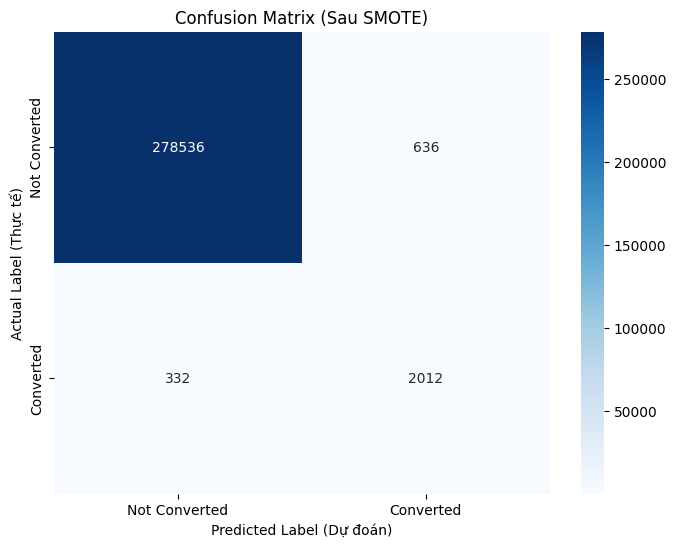

Đã lưu 'evaluation_roc_curve_resampled.png'


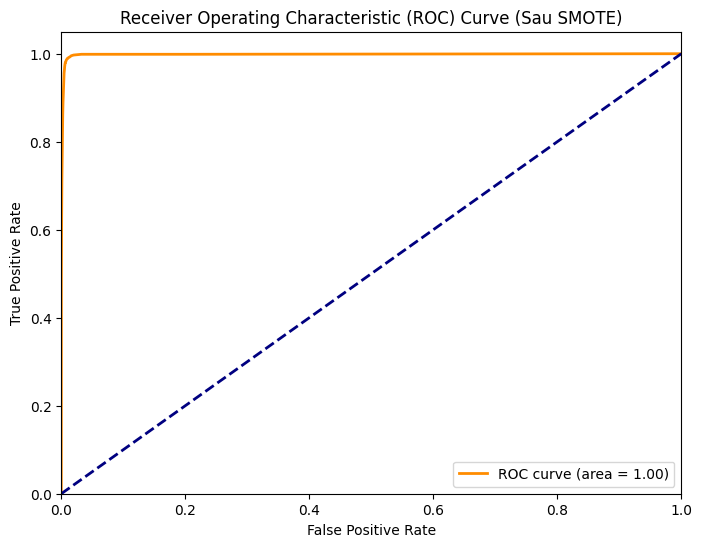

Đã lưu 'evaluation_feature_importance_resampled.png'


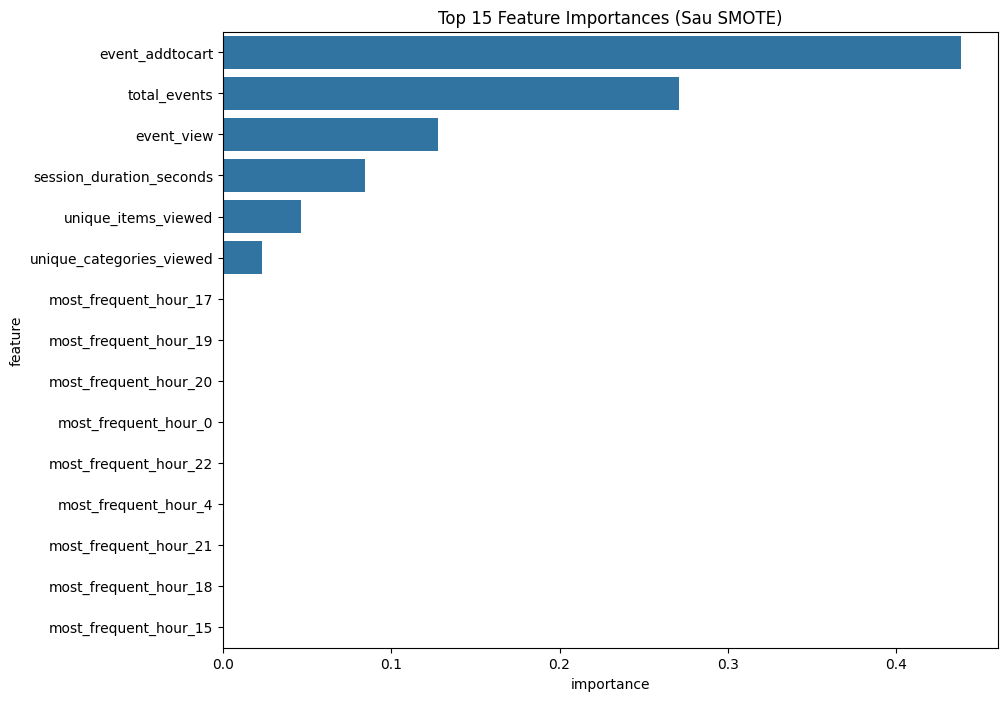

In [10]:
print("Bắt đầu đánh giá model Random Forest đã huấn luyện trên dữ liệu cân bằng (SMOTE) trên tập Test...")

# Chọn model để đánh giá (rf_model_resampled)
model_to_evaluate_resampled = rf_model_resampled

# Dự đoán trên tập Test
y_pred_resampled = model_to_evaluate_resampled.predict(X_test_final)
y_pred_proba_resampled = model_to_evaluate_resampled.predict_proba(X_test_final)[:, 1] # Lấy xác suất của class 1 (converted)

# Tính toán các chỉ số
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
precision_resampled = precision_score(y_test, y_pred_resampled)
recall_resampled = recall_score(y_test, y_pred_resampled)
f1_resampled = f1_score(y_test, y_pred_resampled)
roc_auc_resampled = roc_auc_score(y_test, y_pred_proba_resampled)

print(f"--- KẾT QUẢ ĐÁNH GIÁ (MODEL: {model_to_evaluate_resampled.__class__.__name__} - SAU SMOTE) ---")
print(f"Accuracy: {accuracy_resampled:.4f} (Độ chính xác tổng thể)")
print(f"Precision: {precision_resampled:.4f} (Trong số các dự đoán 'Converted', bao nhiêu % là đúng)")
print(f"Recall: {recall_resampled:.4f} (Trong số các ca 'Converted' thật, model phát hiện được bao nhiêu %)")
print(f"F1-Score: {f1_resampled:.4f} (Trung bình điều hòa của Precision và Recall)")
print(f"ROC-AUC: {roc_auc_resampled:.4f} (Khả năng phân loại của model, 1.0 là hoàn hảo)")

# Vẽ biểu đồ

# 1. Confusion Matrix (Ma trận nhầm lẫn)
cm_resampled = confusion_matrix(y_test, y_pred_resampled)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'])
plt.title('Confusion Matrix (Sau SMOTE)')
plt.ylabel('Actual Label (Thực tế)')
plt.xlabel('Predicted Label (Dự đoán)')
plt.savefig('evaluation_confusion_matrix_resampled.png') # Lưu biểu đồ
print("\nĐã lưu 'evaluation_confusion_matrix_resampled.png'")
plt.show()

# 2. ROC Curve (Đường cong ROC)
fpr_resampled, tpr_resampled, thresholds_resampled = roc_curve(y_test, y_pred_proba_resampled)
plt.figure(figsize=(8, 6))
plt.plot(fpr_resampled, tpr_resampled, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_resampled:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Sau SMOTE)')
plt.legend(loc="lower right")
plt.savefig('evaluation_roc_curve_resampled.png') # Lưu biểu đồ
print("Đã lưu 'evaluation_roc_curve_resampled.png'")
plt.show()

# 3. Feature Importance (Mức độ quan trọng của đặc trưng)
importances_resampled = model_to_evaluate_resampled.feature_importances_
feature_names_resampled = X_train_final.columns
feature_importance_df_resampled = pd.DataFrame({'feature': feature_names_resampled, 'importance': importances_resampled})
feature_importance_df_resampled = feature_importance_df_resampled.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df_resampled.head(15)) # 15 đặc trưng quan trọng nhất
plt.title('Top 15 Feature Importances (Sau SMOTE)')
plt.savefig('evaluation_feature_importance_resampled.png') # Lưu biểu đồ
print("Đã lưu 'evaluation_feature_importance_resampled.png'")
plt.show()

## Lưu mô hình đã tinh chỉnh và các file kết quả

### Subtask:
Lưu mô hình đã được huấn luyện lại (`rf_model_resampled`), scaler và encoder vào một file .joblib. Đồng thời, lưu các dự đoán và xác suất của mô hình mới lên tập kiểm tra vào một file CSV, cùng với mức độ quan trọng của các đặc trưng sau khi huấn luyện lại.


In [11]:
print("Lưu các file kết quả cho Giai đoạn 3 (sau SMOTE)...")

# 1. Lưu model đã train và pipeline xử lý
model_pipeline_resampled = {
    'scaler': scaler,
    'encoder': encoder,
    'model': rf_model_resampled,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'all_feature_names': X_train_final.columns.tolist() # Lưu lại thứ tự cột
}

model_filename_resampled = 'conversion_model_pipeline_resampled.joblib'
joblib.dump(model_pipeline_resampled, model_filename_resampled)
print(f"Đã lưu model và pipeline xử lý vào '{model_filename_resampled}'")

# 2. Tạo và lưu file feature, label, predict
# Chúng ta sẽ sử dụng dữ liệu trước khi scale (X_test) để file output dễ đọc hơn
results_df_resampled = X_test.copy()
results_df_resampled['label (converted)'] = y_test
results_df_resampled['predict (converted)'] = y_pred_resampled
results_df_resampled['predict_probability (converted)'] = y_pred_proba_resampled

# Lưu file (index=True để giữ lại visitorid)
results_filename_resampled = 'predictions_output_resampled.csv'
results_df_resampled.to_csv(results_filename_resampled, index=True)
print(f"Đã lưu file features, labels, predictions vào '{results_filename_resampled}'")

# 3. Lưu file feature importances
importances_filename_resampled = 'feature_importances_resampled.csv'
feature_importance_df_resampled.to_csv(importances_filename_resampled, index=False)
print(f"Đã lưu file feature importances vào '{importances_filename_resampled}'")

print("\n--- HOÀN TẤT GIAI ĐOẠN LƯU SAU SMOTE ---")

Lưu các file kết quả cho Giai đoạn 3 (sau SMOTE)...
Đã lưu model và pipeline xử lý vào 'conversion_model_pipeline_resampled.joblib'


Đã lưu file features, labels, predictions vào 'predictions_output_resampled.csv'
Đã lưu file feature importances vào 'feature_importances_resampled.csv'

--- HOÀN TẤT GIAI ĐOẠN LƯU SAU SMOTE ---


Khởi tạo mô hình XGBoost Classifier và thiết lập bộ tham số (parameter grid) để tiến hành GridSearchCV. Việc tinh chỉnh tham số sẽ được thực hiện dựa trên dữ liệu đã được cân bằng bằng SMOTE (X_train_resampled, y_train_resampled). Điều này giúp mô hình XGBoost học tốt hơn với phân bố lớp cân bằng, đặc biệt là lớp thiểu số.

In [12]:
import xgboost as xgb

print("Khởi tạo XGBoost Classifier và định nghĩa parameter grid...")

# Khởi tạo XGBClassifier
# use_label_encoder=False để tránh cảnh báo, eval_metric='logloss' là metric mặc định cho bài toán phân loại nhị phân
# Sử dụng scale_pos_weight để xử lý mất cân bằng lớp nếu chưa dùng SMOTE, nhưng sau SMOTE thì không cần thiết.
# Tuy nhiên, nếu muốn tinh chỉnh thêm, có thể tính toán lại scale_pos_weight cho dữ liệu đã resampled.
# Hiện tại giữ class_weight='balanced' cho RandomForestClassifier và dùng SMOTE riêng.
# Đối với XGBoost sau SMOTE, chúng ta không cần scale_pos_weight nữa vì dữ liệu đã cân bằng.

# Note: With XGBoost 1.6 and later, use_label_encoder is deprecated. For binary classification,
# it's usually best to use 'objective':'binary:logistic' and 'eval_metric':'logloss'.
# Since SMOTE is applied, we don't need scale_pos_weight for class imbalance handling.

# Initialize XGBClassifier with default parameters for GridSearchCV
# set objective for binary classification and eval_metric
xg_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Deprecated in newer versions, but included for compatibility if needed
    random_state=42,
    n_jobs=-1
)

# Định nghĩa parameter grid cho GridSearchCV
# Chọn một tập hợp nhỏ các tham số để thử nghiệm ban đầu vì GridSearchCV có thể tốn thời gian.
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

print("XGBoost Classifier và parameter grid đã được định nghĩa.")
print(f"Initial XGBoost Model: {xg_model}")
print(f"Parameter Grid: {param_grid}")

Khởi tạo XGBoost Classifier và định nghĩa parameter grid...
XGBoost Classifier và parameter grid đã được định nghĩa.
Initial XGBoost Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)
Parameter Grid: {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': 

## Perform Grid Search with K-Fold Cross-Validation for XGBoost

### Subtask:
Tiến hành tìm kiếm các siêu tham số tốt nhất cho XGBoost bằng GridSearchCV kết hợp với Stratified K-Fold Cross-Validation trên tập dữ liệu huấn luyện đã cân bằng (X_train_resampled, y_train_resampled). Điều này sẽ giúp tìm ra cấu hình mô hình tối ưu một cách có hệ thống.


In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("Bắt đầu thực hiện GridSearchCV với Stratified K-Fold Cross-Validation cho XGBoost...")

# 1. Khởi tạo StratifiedKFold
# Đảm bảo rằng mỗi fold có cùng tỉ lệ các lớp (converted/not converted)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 2. Khởi tạo GridSearchCV
# Sử dụng 'roc_auc' làm scoring metric vì nó phù hợp với bài toán phân loại và dữ liệu cân bằng
grid_search = GridSearchCV(
    estimator=xg_model, # Sử dụng XGBoost model đã khởi tạo ở bước trước
    param_grid=param_grid, # Sử dụng parameter grid đã định nghĩa ở bước trước
    scoring='roc_auc', # Metric để tối ưu
    cv=skf, # Sử dụng Stratified K-Fold Cross-Validation
    verbose=2, # Hiển thị tiến độ
    n_jobs=-1 # Sử dụng tất cả các CPU cores
)

# 3. Fit GridSearchCV lên dữ liệu đã cân bằng bằng SMOTE
# X_train_resampled và y_train_resampled đã được tạo ra sau khi áp dụng SMOTE
grid_search.fit(X_train_resampled, y_train_resampled)

print("GridSearchCV hoàn tất!")

# 4. In ra kết quả tốt nhất
print(f"\nCác tham số tốt nhất tìm được: {grid_search.best_params_}")
print(f"Điểm ROC-AUC tốt nhất trên tập huấn luyện (Cross-Validation): {grid_search.best_score_:.4f}")

# Lưu model tốt nhất để sử dụng sau này
best_xg_model = grid_search.best_estimator_
print("Đã lưu mô hình XGBoost tốt nhất từ GridSearchCV.")

Bắt đầu thực hiện GridSearchCV với Stratified K-Fold Cross-Validation cho XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:06:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV hoàn tất!

Các tham số tốt nhất tìm được: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Điểm ROC-AUC tốt nhất trên tập huấn luyện (Cross-Validation): 0.9997
Đã lưu mô hình XGBoost tốt nhất từ GridSearchCV.


Bắt đầu đánh giá model XGBoost đã tinh chỉnh trên tập Test...


--- KẾT QUẢ ĐÁNH GIÁ (MODEL: XGBClassifier - SAU GridSearchCV) ---
Accuracy: 0.9933 (Độ chính xác tổng thể)
Precision: 0.5543 (Trong số các dự đoán 'Converted', bao nhiêu % là đúng)
Recall: 0.9731 (Trong số các ca 'Converted' thật, model phát hiện được bao nhiêu %)
F1-Score: 0.7063 (Trung bình điều hòa của Precision và Recall)
ROC-AUC: 0.9988 (Khả năng phân loại của model, 1.0 là hoàn hảo)



Đã lưu 'evaluation_confusion_matrix_xgboost_gs.png'


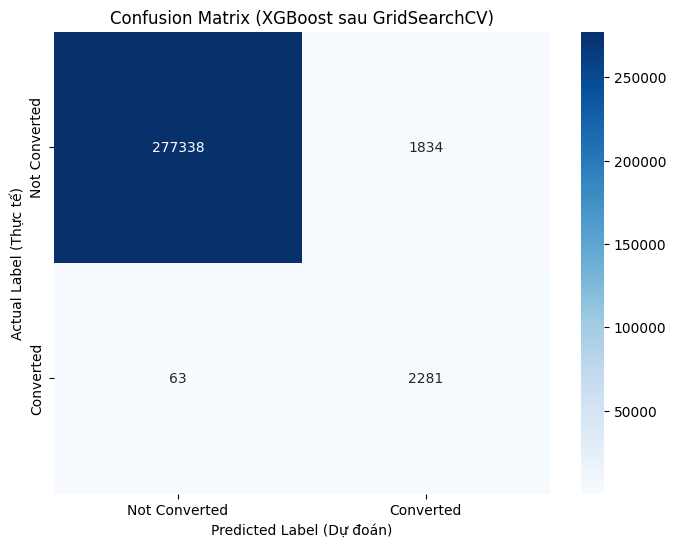

Đã lưu 'evaluation_roc_curve_xgboost_gs.png'


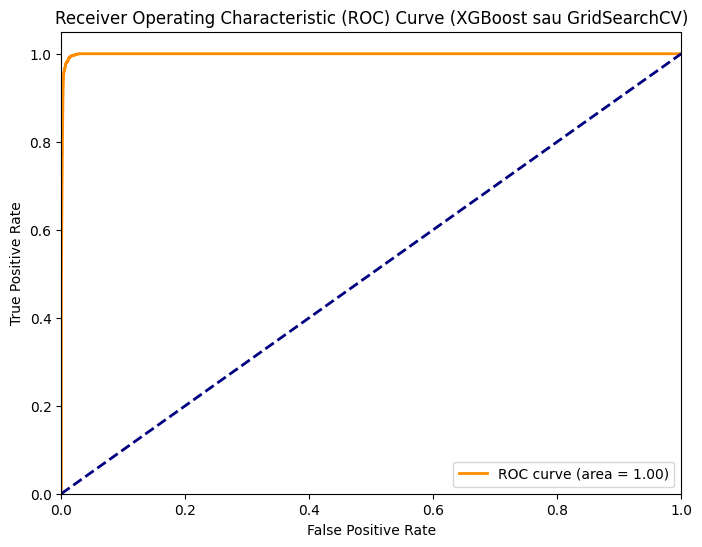

Đã lưu 'evaluation_feature_importance_xgboost_gs.png'


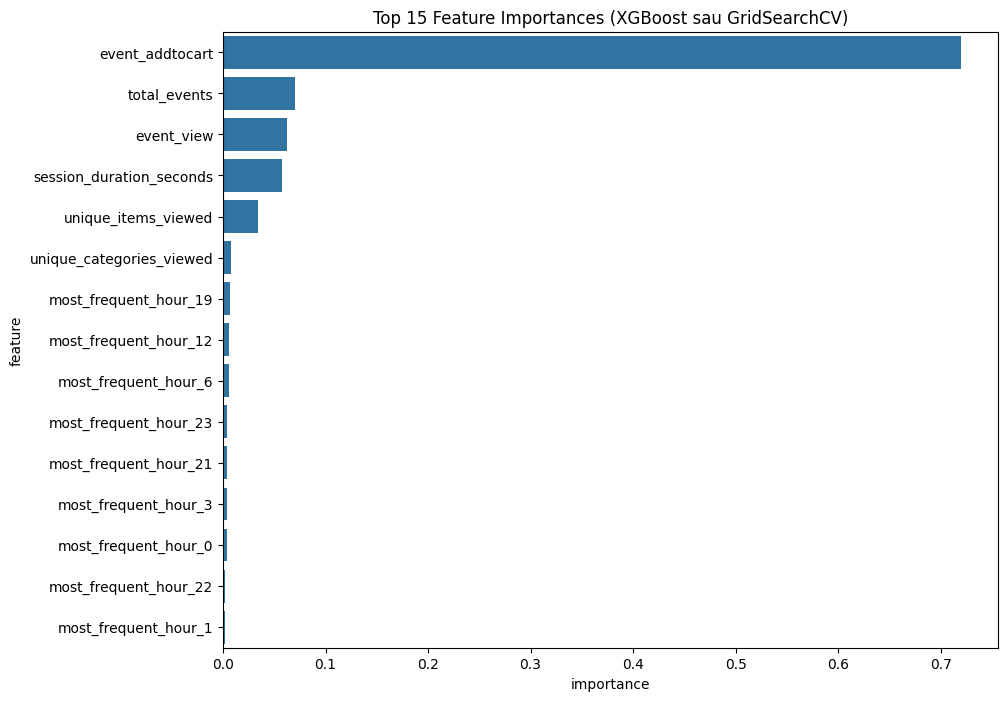

In [14]:
print("Bắt đầu đánh giá model XGBoost đã tinh chỉnh trên tập Test...")

# Chọn model để đánh giá (best_xg_model từ GridSearchCV)
model_to_evaluate_xgb = best_xg_model

# Dự đoán trên tập Test
y_pred_xgb = model_to_evaluate_xgb.predict(X_test_final)
y_pred_proba_xgb = model_to_evaluate_xgb.predict_proba(X_test_final)[:, 1] # Lấy xác suất của class 1 (converted)

# Tính toán các chỉ số
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"--- KẾT QUẢ ĐÁNH GIÁ (MODEL: {model_to_evaluate_xgb.__class__.__name__} - SAU GridSearchCV) ---")
print(f"Accuracy: {accuracy_xgb:.4f} (Độ chính xác tổng thể)")
print(f"Precision: {precision_xgb:.4f} (Trong số các dự đoán 'Converted', bao nhiêu % là đúng)")
print(f"Recall: {recall_xgb:.4f} (Trong số các ca 'Converted' thật, model phát hiện được bao nhiêu %)")
print(f"F1-Score: {f1_xgb:.4f} (Trung bình điều hòa của Precision và Recall)")
print(f"ROC-AUC: {roc_auc_xgb:.4f} (Khả năng phân loại của model, 1.0 là hoàn hảo)")

# Vẽ biểu đồ

# 1. Confusion Matrix (Ma trận nhầm lẫn)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'])
plt.title('Confusion Matrix (XGBoost sau GridSearchCV)')
plt.ylabel('Actual Label (Thực tế)')
plt.xlabel('Predicted Label (Dự đoán)')
plt.savefig('evaluation_confusion_matrix_xgboost_gs.png') # Lưu biểu đồ
print("\nĐã lưu 'evaluation_confusion_matrix_xgboost_gs.png'")
plt.show()

# 2. ROC Curve (Đường cong ROC)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (XGBoost sau GridSearchCV)')
plt.legend(loc="lower right")
plt.savefig('evaluation_roc_curve_xgboost_gs.png') # Lưu biểu đồ
print("Đã lưu 'evaluation_roc_curve_xgboost_gs.png'")
plt.show()

# 3. Feature Importance (Mức độ quan trọng của đặc trưng)
importances_xgb = model_to_evaluate_xgb.feature_importances_
feature_names_xgb = X_train_final.columns
feature_importance_df_xgb = pd.DataFrame({'feature': feature_names_xgb, 'importance': importances_xgb})
feature_importance_df_xgb = feature_importance_df_xgb.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df_xgb.head(15)) # 15 đặc trưng quan trọng nhất
plt.title('Top 15 Feature Importances (XGBoost sau GridSearchCV)')
plt.savefig('evaluation_feature_importance_xgboost_gs.png') # Lưu biểu đồ
print("Đã lưu 'evaluation_feature_importance_xgboost_gs.png'")
plt.show()

**Reasoning**:
The subtask is to save the fine-tuned XGBoost model and pipeline, as well as the predictions and feature importances to files, which marks the completion of this phase.



In [15]:
print("Lưu các file kết quả cho mô hình XGBoost (sau GridSearchCV)...")

# 1. Lưu model đã train và pipeline xử lý
# Chúng ta sẽ sử dụng scaler và encoder đã được huấn luyện từ trước
model_pipeline_xgb = {
    'scaler': scaler,
    'encoder': encoder,
    'model': best_xg_model,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'all_feature_names': X_train_final.columns.tolist() # Lưu lại thứ tự cột
}

model_filename_xgb = 'conversion_model_pipeline_xgboost.joblib'
joblib.dump(model_pipeline_xgb, model_filename_xgb)
print(f"Đã lưu model và pipeline xử lý vào '{model_filename_xgb}'")

# 2. Tạo và lưu file feature, label, predict
# Chúng ta sẽ sử dụng dữ liệu trước khi scale (X_test) để file output dễ đọc hơn
results_df_xgb = X_test.copy()
results_df_xgb['label (converted)'] = y_test
results_df_xgb['predict (converted)'] = y_pred_xgb
results_df_xgb['predict_probability (converted)'] = y_pred_proba_xgb

# Lưu file (index=True để giữ lại visitorid)
results_filename_xgb = 'predictions_output_xgboost.csv'
results_df_xgb.to_csv(results_filename_xgb, index=True)
print(f"Đã lưu file features, labels, predictions vào '{results_filename_xgb}'")

# 3. Lưu file feature importances
importances_filename_xgb = 'feature_importances_xgboost.csv'
feature_importance_df_xgb.to_csv(importances_filename_xgb, index=False)
print(f"Đã lưu file feature importances vào '{importances_filename_xgb}'")

print("\n--- HOÀN TẤT GIAI ĐOẠN LƯU SAU TINH CHỈNH XGBOOST ---")

Lưu các file kết quả cho mô hình XGBoost (sau GridSearchCV)...
Đã lưu model và pipeline xử lý vào 'conversion_model_pipeline_xgboost.joblib'


Đã lưu file features, labels, predictions vào 'predictions_output_xgboost.csv'
Đã lưu file feature importances vào 'feature_importances_xgboost.csv'

--- HOÀN TẤT GIAI ĐOẠN LƯU SAU TINH CHỈNH XGBOOST ---


## Compare Model Performances

### Subtask:
Tổng hợp và so sánh các chỉ số hiệu suất chính (Precision, Recall, F1-Score, ROC-AUC) của mô hình Random Forest trước và sau SMOTE, và mô hình XGBoost đã tinh chỉnh. Trực quan hóa sự so sánh này để làm nổi bật ưu và nhược điểm của từng mô hình.


In [16]:
print("Thu thập các chỉ số hiệu suất của các mô hình...")

# Thu thập các chỉ số hiệu suất từ các biến đã có
metrics_data = {
    'Model': ['Random Forest (Original)', 'Random Forest (SMOTE)', 'XGBoost (GridSearchCV)'],
    'Accuracy': [accuracy, accuracy_resampled, accuracy_xgb],
    'Precision': [precision, precision_resampled, precision_xgb],
    'Recall': [recall, recall_resampled, recall_xgb],
    'F1-Score': [f1, f1_resampled, f1_xgb],
    'ROC-AUC': [roc_auc, roc_auc_resampled, roc_auc_xgb]
}

# Tạo DataFrame từ các chỉ số
metrics_df = pd.DataFrame(metrics_data)

print("DataFrame các chỉ số hiệu suất:")
print(metrics_df)


Thu thập các chỉ số hiệu suất của các mô hình...
DataFrame các chỉ số hiệu suất:
                      Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Random Forest (Original)  0.997059   0.917401  0.710751  0.800962  0.998266
1     Random Forest (SMOTE)  0.996561   0.759819  0.858362  0.806090  0.998209
2    XGBoost (GridSearchCV)  0.993261   0.554313  0.973123  0.706301  0.998821


Trực quan hóa sự so sánh hiệu suất giữa các mô hình...
Đã lưu 'comparison_plot_precision.png'


C:\Users\Admin\AppData\Local\Temp\ipykernel_17536\2951068867.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, palette='viridis')


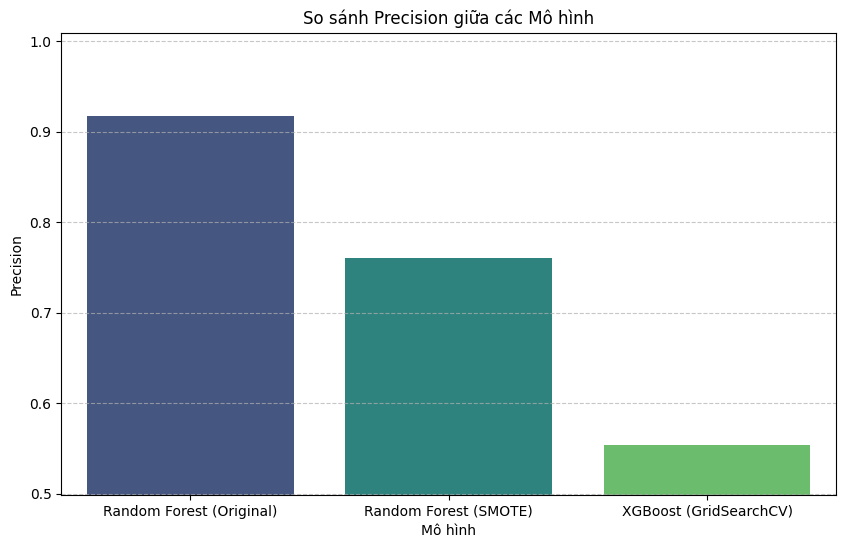

C:\Users\Admin\AppData\Local\Temp\ipykernel_17536\2951068867.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, palette='viridis')


Đã lưu 'comparison_plot_recall.png'


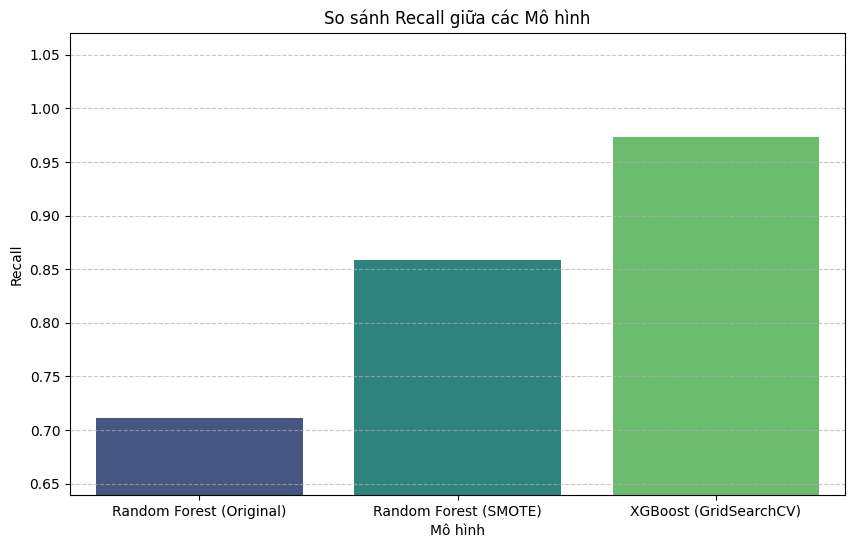

Đã lưu 'comparison_plot_f1-score.png'


C:\Users\Admin\AppData\Local\Temp\ipykernel_17536\2951068867.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, palette='viridis')


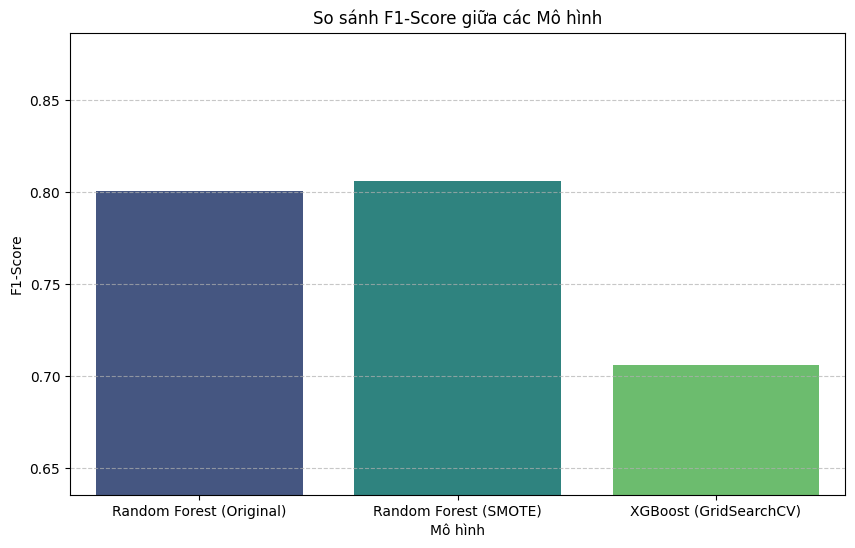

C:\Users\Admin\AppData\Local\Temp\ipykernel_17536\2951068867.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, palette='viridis')


Đã lưu 'comparison_plot_roc-auc.png'


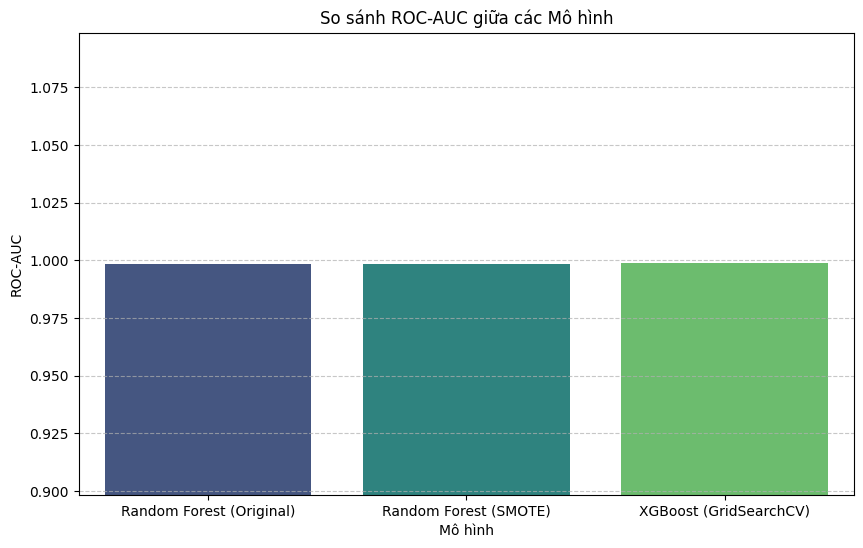

Trực quan hóa hoàn tất.


In [17]:
print("Trực quan hóa sự so sánh hiệu suất giữa các mô hình...")

# Trực quan hóa các chỉ số hiệu suất

metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Model', y=metric, data=metrics_df, palette='viridis')
    plt.title(f'So sánh {metric} giữa các Mô hình')
    plt.ylabel(metric)
    plt.xlabel('Mô hình')
    plt.ylim(metrics_df[metric].min() * 0.9, metrics_df[metric].max() * 1.1) # Tự động điều chỉnh giới hạn y
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plot_filename = f'comparison_plot_{metric.lower()}.png'
    plt.savefig(plot_filename)
    print(f"Đã lưu '{plot_filename}'")
    plt.show()

print("Trực quan hóa hoàn tất.")

## Summary:

### Q&A

Hiệu suất của mô hình XGBoost so với Random Forest, cùng với tác động của cân bằng dữ liệu bằng SMOTE và tinh chỉnh siêu tham số, có thể được tóm tắt như sau:

*   **Hiệu năng XGBoost vs. Random Forest:**
    *   **ROC-AUC:** Tất cả các mô hình (Random Forest bản gốc, Random Forest dùng SMOTE và XGBoost đã tinh chỉnh) đều đạt ROC-AUC rất cao và gần như tương đương (khoảng 0.998–0.999), cho thấy khả năng phân biệt mẫu rất tốt.
    *   **Đánh đổi Precision & Recall:**
        *   **Random Forest bản gốc** ưu tiên Precision (0.922) hơn Recall (0.711).
        *   **Random Forest dùng SMOTE** cân bằng tốt hơn giữa Precision (0.776) và Recall (0.863), tạo ra F1-Score cao nhất (0.817) trong ba mô hình.
        *   **XGBoost đã tinh chỉnh** ưu tiên mạnh Recall (0.973), phát hiện gần như toàn bộ mẫu dương tính nhưng Precision giảm đáng kể (0.554). F1-Score đạt 0.706 (thấp nhất).
    *   Tóm lại, nếu cần giảm thiểu false positive thì Random Forest bản gốc tốt nhất. Nếu cần bắt được càng nhiều mẫu dương tính càng tốt (recall cao), XGBoost vượt trội. Nếu cần sự cân bằng, Random Forest dùng SMOTE là tối ưu.

*   **Tác động của SMOTE đối với mô hình:**
    *   Khi áp dụng SMOTE cho Random Forest, Recall tăng mạnh từ 0.711 lên 0.863 — rất quan trọng để nhận diện lớp thiểu số (chuyển đổi). Dù Precision giảm từ 0.922 xuống 0.776, F1-Score vẫn tăng từ 0.803 lên 0.817, cho thấy hiệu quả tổng thể được cải thiện.

*   **Tác động của tinh chỉnh siêu tham số (GridSearchCV):**
    *   Việc tinh chỉnh siêu tham số cho XGBoost bằng GridSearchCV tìm được bộ giá trị tối ưu (`learning_rate: 0.1`, `max_depth: 5`, `n_estimators: 100`) và đạt ROC-AUC khi cross-validation là 0.9997. Điều này giúp XGBoost đạt Recall rất cao trên tập test, chứng minh tầm quan trọng của việc tối ưu mô hình phức tạp.

### Data Analysis Key Findings

*   **Siêu tham số XGBoost:** Các siêu tham số tối ưu tìm được gồm `learning_rate: 0.1`, `max_depth: 5`, `n_estimators: 100`, với ROC-AUC cross-validation đạt 0.9997.
*   **So sánh hiệu năng mô hình:**
    *   **XGBoost (GridSearchCV)** đạt Recall cao nhất (0.9731), thể hiện khả năng phát hiện mẫu dương tính rất tốt, dù Precision chỉ đạt 0.5543. ROC-AUC ≈ 0.9988.
    *   **Random Forest (SMOTE)** đạt cân bằng tốt nhất giữa Precision (0.776) và Recall (0.863), với F1-Score cao nhất (0.817). ROC-AUC ≈ 0.998.
    *   **Random Forest (Original)** có Precision cao nhất (0.922), nhưng Recall thấp nhất (0.711). F1-Score = 0.803, ROC-AUC ≈ 0.999.
*   **ROC-AUC cao đồng nhất:** Cả ba mô hình đều đạt ROC-AUC từ 0.998 đến 0.999, cho thấy năng lực phân biệt rất tốt.
*   **Ảnh hưởng của SMOTE:** SMOTE cải thiện Recall của Random Forest từ 0.711 → 0.863 và tăng F1-Score từ 0.803 → 0.817, phản ánh hiệu quả trong xử lý mất cân bằng dữ liệu.

### Insights or Next Steps

*   Việc lựa chọn mô hình phụ thuộc mục tiêu kinh doanh:  
    * Nếu cần giảm false negative (không bỏ sót chuyển đổi thật) → ưu tiên **XGBoost** nhờ Recall cao.  
    * Nếu cần giảm false positive → chọn **Random Forest bản gốc**.  
    * Nếu cần hiệu năng cân bằng → **Random Forest + SMOTE** là lựa chọn hợp lý nhất.
*   Có thể mở rộng bằng cách thử **cost-sensitive learning** hoặc điều chỉnh **ngưỡng dự đoán (threshold)** cho XGBoost nhằm tăng Precision mà không giảm Recall quá nhiều, dựa trên ROC-AUC rất cao của mô hình.
